In [111]:
import pandas as pd

coin = pd.read_csv(
    "/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/mmpair-strategy/mmpair-strategy/1m_klines_raw/DOGEUSDT_klines_1m.csv"
)

# 时间戳统一到微秒
coin["Close Time"] = coin["Close Time"].apply(
    lambda x: x * 1000 + 999 if x < 2000000000000 else x
)
coin["Open Time"] = coin["Open Time"].apply(
    lambda x: x * 1000 if x < 2000000000000 else x
)

# 将时间戳转换为 datetime 格式
coin["Close Time"] = pd.to_datetime(coin["Close Time"], unit="us")
coin["Open Time"] = pd.to_datetime(coin["Open Time"], unit="us")

# 设置索引
coin.set_index("Close Time", inplace=True)
coin.sort_index(inplace=True)

In [112]:
# coin = coin.loc['2024-01-01':'2025-01-01']
coin = coin.loc["2024-06-01":]

In [113]:
coin

,index,Open Time,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore
Close Time,,,,,,,,,,,,
2024-06-01 00:00:59.999999,394560,2024-06-01 00:00:00,0.15898,0.15922,0.15898,0.15922,495505.0,78834.94538,148,386229.0,61445.71215,0
2024-06-01 00:01:59.999999,394561,2024-06-01 00:01:00,0.15921,0.15924,0.15905,0.15910,325228.0,51756.05142,131,102658.0,16335.21016,0
2024-06-01 00:02:59.999999,394562,2024-06-01 00:02:00,0.15909,0.15924,0.15909,0.15923,407533.0,64875.21901,141,172247.0,27421.98670,0
2024-06-01 00:03:59.999999,394563,2024-06-01 00:03:00,0.15923,0.15934,0.15916,0.15932,480372.0,76511.19729,150,314892.0,50161.73320,0
2024-06-01 00:04:59.999999,394564,2024-06-01 00:04:00,0.15931,0.15956,0.15929,0.15950,1640443.0,261457.75200,228,1523884.0,242872.19906,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-31 23:55:59.999999,1140475,2025-10-31 23:55:00,0.18645,0.18649,0.18644,0.18646,52397.0,9770.69328,183,23626.0,4405.51650,0
2025-10-31 23:56:59.999999,1140476,2025-10-31 23:56:00,0.18645,0.18645,0.18636,0.18638,50830.0,9475.30749,141,26566.0,4952.27862,0
2025-10-31 23:57:59.999999,1140477,2025-10-31 23:57:00,0.18638,0.18648,0.18638,0.18648,197856.0,36895.67321,158,189995.0,35429.86404,0


In [114]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置图形风格
plt.style.use("seaborn-v0_8")

In [115]:
deri_window = 1  # 2d
n = int(800)  # VWAP window in 5m
# threshold = 750    # $/d

In [116]:
cum_vol = coin["Volume"].rolling(window=n).sum()
cum_vol_px = (coin["Close"] * coin["Volume"]).rolling(window=n).sum()
coin["VWAP"] = cum_vol_px / cum_vol

In [117]:
cum_vol = coin["Volume"].rolling(window=n).sum()
cum_vol_px = (coin["Close"] * coin["Volume"]).rolling(window=n).sum()
coin["VWAP"] = cum_vol_px / cum_vol
shift_steps = n
coin["VWAP_derivative"] = (coin["VWAP"] - coin["VWAP"].shift(shift_steps)) / deri_window
coin["VWAP_derivative2"] = (
    coin["VWAP_derivative"] - coin["VWAP_derivative"].shift(shift_steps)
) / deri_window
coin["VWAP_derivative3"] = (
    coin["VWAP_derivative2"] - coin["VWAP_derivative2"].shift(shift_steps)
) / deri_window

In [118]:
# 在所有子图上绘制贯穿的竖线并在正区域上色


In [119]:
# 在 VWAP_derivative 和 VWAP_derivative2 都小于0的区域上色


In [120]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# # Plot Close and VWAP on the first subplot
# ax1.plot(coin["Close"], label="Close", alpha=0.6)
# ax1.plot(coin["VWAP"], label="VWAP", color="blue")
# ax1.set_ylabel("Price")
# ax1.set_title("VWAP and VWAP_derivative")
# ax1.legend(loc="upper left")

# # Plot VWAP_derivative on the second subplot
# ax2.plot(coin["VWAP_derivative"], label="VWAP_derivative", color="orange")
# ax2.set_ylabel("VWAP_derivative")
# ax2.legend(loc="upper left")

# # Plot VWAP_derivative2 on the third subplot
# ax3.plot(coin["VWAP_derivative2"], label="VWAP_derivative2", color="red")
# ax3.set_ylabel("VWAP_derivative2")
# ax3.legend(loc="upper left")

# # Set the x-axis label for the bottom subplot
# ax3.set_xlabel("Time")

# # 在 ax2 和 ax3 上绘制 y=0 的横线
# ax2.axhline(0, color='gray', linestyle='--', linewidth=1, label='y=0')
# ax3.axhline(0, color='gray', linestyle='--', linewidth=1, label='y=0')

# # 找到 VWAP_derivative 和 VWAP_derivative2 与 y=0 的交点
# cross_points_derivative = coin[coin["VWAP_derivative"] * coin["VWAP_derivative"].shift(1) < 0]
# cross_points_derivative2 = coin[coin["VWAP_derivative2"] * coin["VWAP_derivative2"].shift(1) < 0]


# for cross_time in cross_points_derivative.index:
#   ax1.axvline(cross_time, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
#   ax2.axvline(cross_time, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
#   ax3.axvline(cross_time, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)

# for cross_time in cross_points_derivative2.index:
#   ax1.axvline(cross_time, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
#   ax2.axvline(cross_time, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
#   ax3.axvline(cross_time, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

# # 在 VWAP_derivative 和 VWAP_derivative2 都大于0的区域上色
# positive_region = (coin["VWAP_derivative"] > 0) & (coin["VWAP_derivative2"] > 0)
# for start, end in zip(positive_region[positive_region].index[:-1], positive_region[positive_region].index[1:]):
#   if (end - start).total_seconds() / 60 == 5:  # 确保连续区域
#     ax1.axvspan(start, end, color='yellow', alpha=0.2)
#     ax2.axvspan(start, end, color='yellow', alpha=0.2)
#     ax3.axvspan(start, end, color='yellow', alpha=0.2)

# positive_region = (coin["VWAP_derivative"] < 0) & (coin["VWAP_derivative2"] < 0)
# for start, end in zip(positive_region[positive_region].index[:-1], positive_region[positive_region].index[1:]):
#   if (end - start).total_seconds() / 60 == 5:  # 确保连续区域
#     ax1.axvspan(start, end, color='blue', alpha=0.03)
#     ax2.axvspan(start, end, color='blue', alpha=0.03)
#     ax3.axvspan(start, end, color='blue', alpha=0.03)
# # 显示更新后的图形
# fig.canvas.draw()

# plt.tight_layout()
# plt.show()

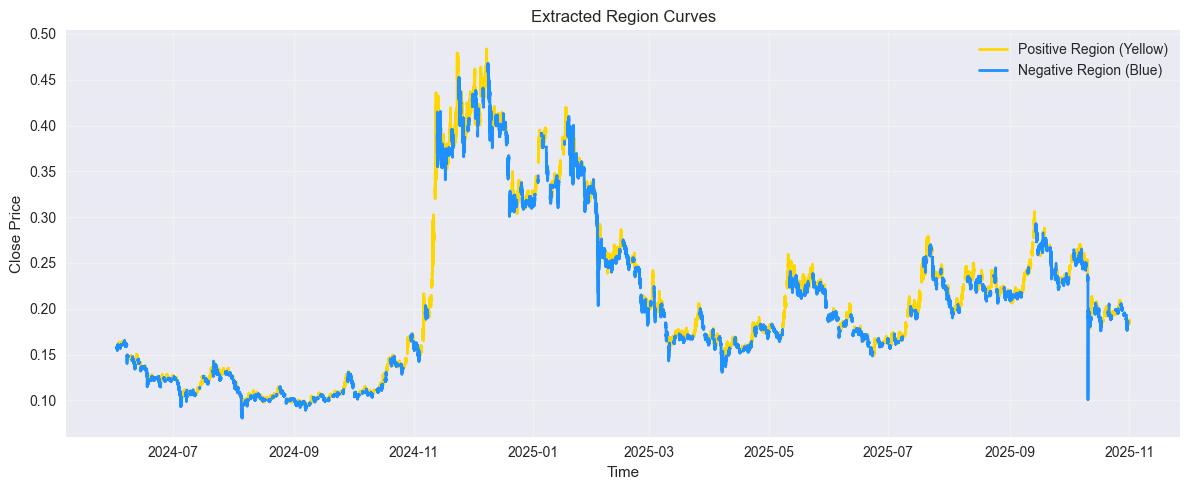

In [121]:
import matplotlib.pyplot as plt
import pandas as pd

# ===== 假设 coin 是你的原始 DataFrame =====
# 这里示例直接用 coin 中的 VWAP_derivative 和 VWAP_derivative2

# 1️⃣ 定义黄色与蓝色区域的布尔掩码
mask_yellow = (coin["VWAP_derivative"] > 0) & (
    coin["VWAP_derivative2"] > 0 & (coin["VWAP_derivative3"] > 0)
)
mask_blue = (coin["VWAP_derivative"] < 0) & (
    coin["VWAP_derivative2"] < 0 & (coin["VWAP_derivative3"] < 0)
)

# 2️⃣ 生成两条曲线（不满足条件的地方用 NaN 保持时间轴一致）
yellow_curve = np.where(mask_yellow, coin["Close"], np.nan)
blue_curve = np.where(mask_blue, coin["Close"], np.nan)

# 3️⃣ 新 figure 绘图
fig2, ax = plt.subplots(figsize=(12, 5))
ax.plot(coin.index, yellow_curve, color="gold", lw=2, label="Positive Region (Yellow)")
ax.plot(
    coin.index, blue_curve, color="dodgerblue", lw=2, label="Negative Region (Blue)"
)
ax.set_title("Extracted Region Curves")
ax.set_ylabel("Close Price")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [122]:
coin["pos"] = (
    (coin["VWAP_derivative"] > 0) & (coin["VWAP_derivative2"] > 0)
    # & (coin["VWAP_derivative3"] > 0)
)
coin["neg"] = (
    (coin["VWAP_derivative"] < 0) & (coin["VWAP_derivative2"] < 0)
    # & (coin["VWAP_derivative3"] < 0)
)

Processing:   0%|          | 0/745920 [00:00<?, ?it/s]

Processing: 100%|██████████| 745920/745920 [00:08<00:00, 83522.85it/s]


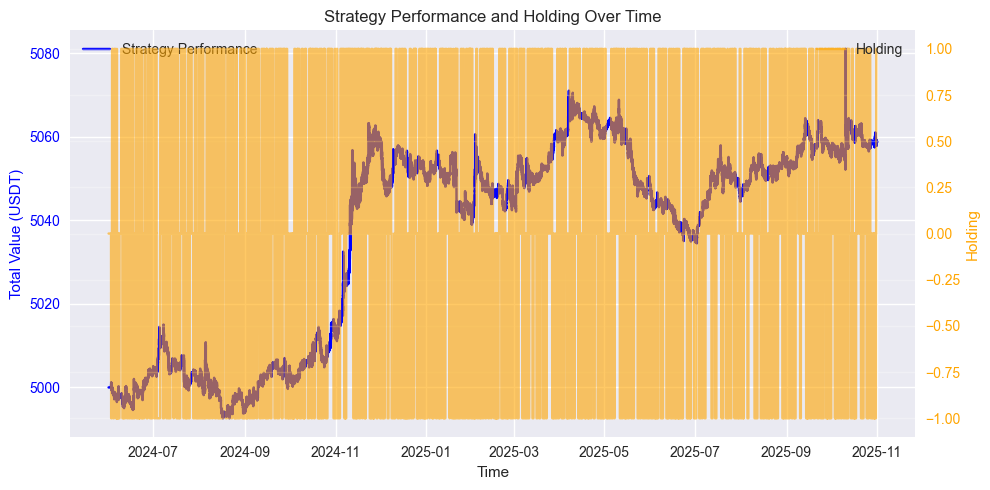

In [123]:
from collections import deque

import numpy as np
import pandas as pd
from tqdm import tqdm


def implement_strategy(
    coin: pd.DataFrame,
    trade_size: float,
    initial_cap: float = 5000.0,
    fee: float = 0.0005,
):
    prices = coin["Close"].values
    n = len(prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap  # USDT
    amount = 0.0  # 持仓coin数量
    open_orders = deque()  # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    for t in tqdm(range(n), desc="Processing"):
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        if t >= 1 and coin["pos"].iloc[t - 1] and now_holding == 0:
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        # --- 卖空信号 ---
        if t >= 1 and coin["neg"].iloc[t - 1] and now_holding == 0:
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital += trade_size - trade_size * fee
                amount -= qty
                now_holding -= 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        if not coin["pos"].iloc[t] and now_holding > 0:
            # 平多仓
            while open_orders and now_holding > 0:
                order = open_orders.popleft()
                sell_qty = order["qty"]
                sell_price = price_t
                proceeds = sell_qty * sell_price * (1 - fee)
                capital += proceeds
                amount -= sell_qty
                now_holding -= 1

                # 计算并记录收益率
                entry_price = order["price"]
                pnl = (sell_price - entry_price) / entry_price
                pnl_records[t] += pnl
        if not coin["neg"].iloc[t] and now_holding < 0:
            # 平空仓
            while open_orders and now_holding < 0:
                order = open_orders.popleft()
                buy_qty = order["qty"]
                buy_price = price_t
                cost = buy_qty * buy_price * (1 + fee)
                capital -= cost
                amount += buy_qty
                now_holding += 1

                # 计算并记录收益率
                entry_price = order["price"]
                pnl = (entry_price - buy_price) / entry_price
                pnl_records[t] += pnl

    # 生成结果
    performance_df = pd.DataFrame({"Total Value": total_value}, index=coin.index)
    holding_series = pd.Series(holdings_array, index=coin.index)
    pnl_series = pd.Series(pnl_records, index=coin.index)
    return performance_df, pnl_series, holding_series


# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(
    coin, trade_size=50.0, initial_cap=5000.0
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()


x = [i * 5 for i in range(len(strategy_performance))]  # 每一行对应的分钟数


# 策略表现
ax1.plot(
    strategy_performance.index,
    strategy_performance["Total Value"],
    label="Strategy Performance",
    color="blue",
)
ax1.set_ylabel("Total Value (USDT)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# 持仓
ax2.plot(
    strategy_performance.index,
    holding.values,
    label="Holding",
    color="orange",
    alpha=0.6,
)
ax2.set_ylabel("Holding", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("Strategy Performance and Holding Over Time")
ax1.set_xlabel("Time")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [133]:
# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 打印前几行以验证
print(non_zero_pnls.head())
# 将 pnls 转换为 numpy 数组以便计算
import numpy as np

pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0])
    / abs(np.mean(pnls_array[pnls_array < 0]))
    if np.any(pnls_array < 0)
    else float("inf"),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array)
    if np.std(pnls_array) > 0
    else 0,
    "总收益率": np.sum(pnls_array),
}

# 打印统计指标
for key, value in stats.items():
    print(
        f"{key}: {value:.4f}"
        if isinstance(value, (float, np.float64))
        else f"{key}: {value}"
    )

Close Time
2024-06-03 03:00:59.999999   -0.009962
2024-06-03 22:04:59.999999   -0.018522
2024-06-04 16:30:59.999999   -0.011516
2024-06-05 15:05:59.999999    0.007052
2024-06-06 01:45:59.999999   -0.002952
dtype: float64
总交易次数: 689
平均收益率: 0.0027
中位数收益率: -0.0027
最大收益率: 0.2550
最小收益率: -0.1343
标准差: 0.0356
正收益交易数: 311
负收益交易数: 378
胜率: 0.4514
盈亏比: 1.5316
夏普比率: 0.0764
总收益率: 1.8728


# 2
dtype: float64
总交易次数: 66
平均收益率: 0.0098
中位数收益率: 0.0051
最大收益率: 0.1770
最小收益率: -0.0847
标准差: 0.0433
正收益交易数: 35
负收益交易数: 31
胜率: 0.5303
盈亏比: 1.6597
夏普比率: 0.2265
总收益率: 0.6477

In [125]:
strategy_performance.index

DatetimeIndex(['2024-06-01 00:00:59.999999', '2024-06-01 00:01:59.999999',
               '2024-06-01 00:02:59.999999', '2024-06-01 00:03:59.999999',
               '2024-06-01 00:04:59.999999', '2024-06-01 00:05:59.999999',
               '2024-06-01 00:06:59.999999', '2024-06-01 00:07:59.999999',
               '2024-06-01 00:08:59.999999', '2024-06-01 00:09:59.999999',
               ...
               '2025-10-31 23:50:59.999999', '2025-10-31 23:51:59.999999',
               '2025-10-31 23:52:59.999999', '2025-10-31 23:53:59.999999',
               '2025-10-31 23:54:59.999999', '2025-10-31 23:55:59.999999',
               '2025-10-31 23:56:59.999999', '2025-10-31 23:57:59.999999',
               '2025-10-31 23:58:59.999999', '2025-10-31 23:59:59.999999'],
              dtype='datetime64[ns]', name='Close Time', length=745920, freq=None)

In [126]:
sp = pd.read_csv("/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/rev-strategy/sp.csv")
sp["Close Time"] = pd.to_datetime(sp["Close Time"])

In [127]:
sp.set_index("Close Time", inplace=True)

In [128]:
sp.index

DatetimeIndex(['2024-09-01 00:04:59.999999', '2024-09-01 00:09:59.999999',
               '2024-09-01 00:14:59.999999', '2024-09-01 00:19:59.999999',
               '2024-09-01 00:24:59.999999', '2024-09-01 00:29:59.999999',
               '2024-09-01 00:34:59.999999', '2024-09-01 00:39:59.999999',
               '2024-09-01 00:44:59.999999', '2024-09-01 00:49:59.999999',
               ...
               '2025-08-31 23:14:59.999999', '2025-08-31 23:19:59.999999',
               '2025-08-31 23:24:59.999999', '2025-08-31 23:29:59.999999',
               '2025-08-31 23:34:59.999999', '2025-08-31 23:39:59.999999',
               '2025-08-31 23:44:59.999999', '2025-08-31 23:49:59.999999',
               '2025-08-31 23:54:59.999999', '2025-08-31 23:59:59.999999'],
              dtype='datetime64[ns]', name='Close Time', length=105120, freq=None)

In [129]:
sp

,Total Value,Peak,Drawdown,Drawdown Start,Drawdown End
Close Time,,,,,
2024-09-01 00:04:59.999999,10000.000000,10000.000000,0.000000,False,False
2024-09-01 00:09:59.999999,10000.000000,10000.000000,0.000000,False,False
2024-09-01 00:14:59.999999,10000.000000,10000.000000,0.000000,False,False
2024-09-01 00:19:59.999999,10000.000000,10000.000000,0.000000,False,False
2024-09-01 00:24:59.999999,10000.000000,10000.000000,0.000000,False,False
...,...,...,...,...,...
2025-08-31 23:39:59.999999,11614.754646,11745.090588,-0.011097,False,False
2025-08-31 23:44:59.999999,11614.754646,11745.090588,-0.011097,False,False
2025-08-31 23:49:59.999999,11614.754646,11745.090588,-0.011097,False,False


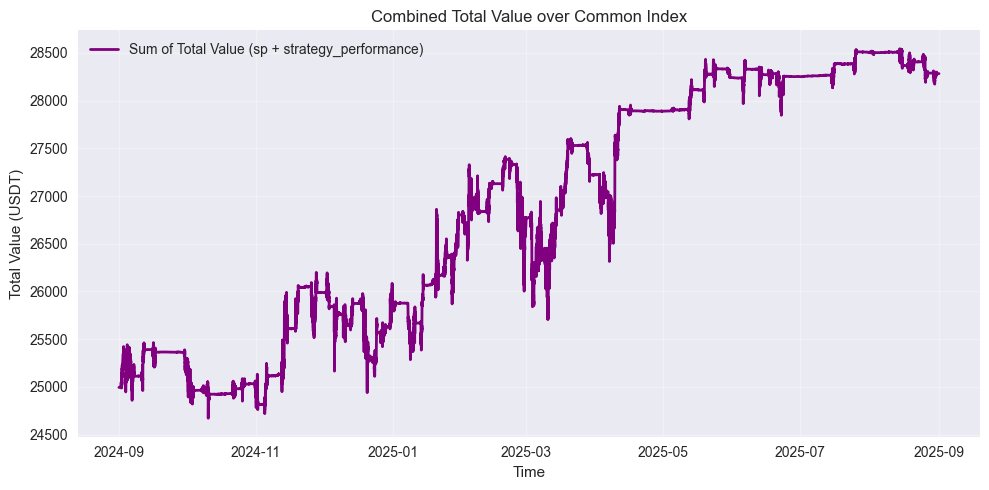

In [130]:
import matplotlib.pyplot as plt

# 1️⃣ 取时间索引交集并排序
common_index = sp.index.intersection(strategy_performance.index).sort_values()

# 2️⃣ 对齐后求和
total_sum = (
    sp.loc[common_index, "Total Value"] * 2
    + strategy_performance.loc[common_index, "Total Value"]
)

# 3️⃣ 画图
plt.figure(figsize=(10, 5))
plt.plot(
    common_index,
    total_sum,
    color="purple",
    lw=2,
    label="Sum of Total Value (sp + strategy_performance)",
)
plt.title("Combined Total Value over Common Index")
plt.xlabel("Time")
plt.ylabel("Total Value (USDT)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [131]:
total_sum.to_csv(
    "/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/trend_strategy/total_sum.csv"
)

In [132]:
common_index

DatetimeIndex(['2024-09-01 00:04:59.999999', '2024-09-01 00:09:59.999999',
               '2024-09-01 00:14:59.999999', '2024-09-01 00:19:59.999999',
               '2024-09-01 00:24:59.999999', '2024-09-01 00:29:59.999999',
               '2024-09-01 00:34:59.999999', '2024-09-01 00:39:59.999999',
               '2024-09-01 00:44:59.999999', '2024-09-01 00:49:59.999999',
               ...
               '2025-08-31 23:14:59.999999', '2025-08-31 23:19:59.999999',
               '2025-08-31 23:24:59.999999', '2025-08-31 23:29:59.999999',
               '2025-08-31 23:34:59.999999', '2025-08-31 23:39:59.999999',
               '2025-08-31 23:44:59.999999', '2025-08-31 23:49:59.999999',
               '2025-08-31 23:54:59.999999', '2025-08-31 23:59:59.999999'],
              dtype='datetime64[ns]', name='Close Time', length=105120, freq='5min')